In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import os
from sklearn.preprocessing import RobustScaler
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import os
from sklearn.preprocessing import RobustScaler
from datetime import datetime

In [3]:
#Ruta al directorio base y del archivo Silver
BASE_DIR = os.path.abspath(os.path.join(os.path.dirname('__file__'), "..", ".."))
SILVER_DIR = os.path.join(BASE_DIR, "data", "capa_silver")
SILVER_FILE_PATH = os.path.join(SILVER_DIR, "silver_data.parquet")
VARIABLES_CONTINUAS = [
    "voltaje",
    "corriente_carga",
    "temperatura_aceite",
    "temperatura_aceite_OLTC",
    "temperatura_ambiente",
    "temperatura_punto_caliente",
    "temperatura_burbujeo",
    "potencia_aparente",
]
VARIABLES_DISCRETAS = [
    "tap_position"
]

# Cargar el dataset Silver
try:
    df_gold = pd.read_parquet(SILVER_FILE_PATH)
    print(f"Dimensiones del DataFrame: {df_gold.shape}")
    print(display(df_gold.head()))
    print("\nInformacion del DataFrame:")
    df_gold.info()
except Exception as e:
    print(f"Ocurrio un error al cargar los datos Silver: {e}")

Dimensiones del DataFrame: (30912, 9)


,voltaje,corriente_carga,temperatura_aceite,temperatura_aceite_OLTC,temperatura_ambiente,temperatura_punto_caliente,temperatura_burbujeo,potencia_aparente,tap_position
timestamp,,,,,,,,,
2024-09-10 04:00:00,131.041825,739.327177,51.534286,47.685000,26.500000,56.185879,178.928398,30.745757,10
2024-09-10 04:15:00,130.693073,728.593612,53.500000,49.825000,26.650000,58.642727,178.854984,30.232734,11
2024-09-10 04:30:00,130.812457,715.310359,53.342857,50.025000,26.800000,58.308074,178.781570,29.725678,11
2024-09-10 04:45:00,130.924854,701.814300,53.185714,49.739999,26.600000,57.973421,178.411140,29.164683,11
2024-09-10 05:00:00,130.564417,688.681148,53.028571,48.650999,26.233334,57.638768,176.250397,28.610652,11


None

Informacion del DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30912 entries, 2024-09-10 04:00:00 to 2025-07-29 03:45:00
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   voltaje                     30912 non-null  float64
 1   corriente_carga             30912 non-null  float64
 2   temperatura_aceite          30912 non-null  float64
 3   temperatura_aceite_OLTC     30912 non-null  float64
 4   temperatura_ambiente        30912 non-null  float64
 5   temperatura_punto_caliente  30912 non-null  float64
 6   temperatura_burbujeo        30912 non-null  float64
 7   potencia_aparente           30912 non-null  float64
 8   tap_position                30912 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 2.4 MB


In [4]:
print("Silver shape:", df_gold.shape)
print("Silver index min/max:", df_gold.index.min(), df_gold.index.max())
print("Tail Silver:", df_gold.tail(3).index.tolist())


Silver shape: (30912, 9)
Silver index min/max: 2024-09-10 04:00:00 2025-07-29 03:45:00
Tail Silver: [Timestamp('2025-07-29 03:15:00'), Timestamp('2025-07-29 03:30:00'), Timestamp('2025-07-29 03:45:00')]



ANÁLISIS DE AUTOCORRELACIÓN: TEMPERATURA_PUNTO_CALIENTE


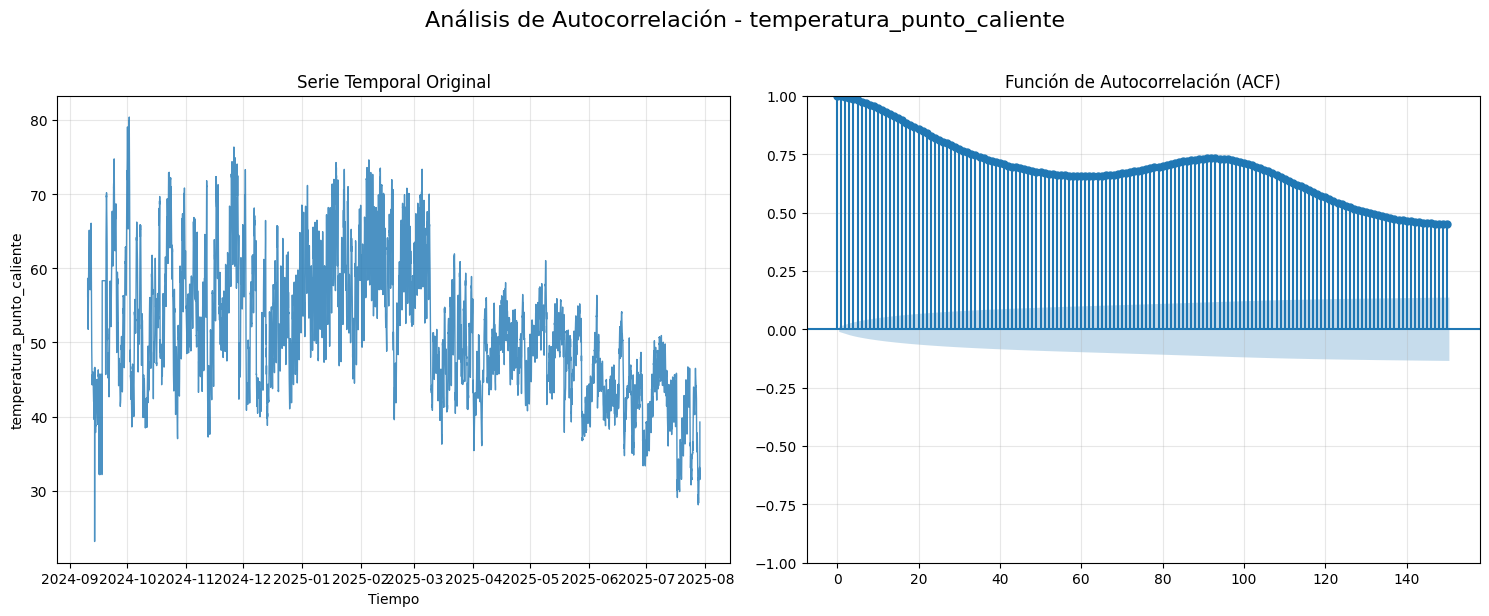


📊 ESTADÍSTICAS DE AUTOCORRELACIÓN - temperatura_punto_caliente
Observaciones: 30912
Límite de confianza (95%): ±0.0111

🔍 Lags significativos en ACF:
  Lag 1: 0.9979
  Lag 2: 0.9949
  Lag 3: 0.9910
  Lag 4: 0.9865
  Lag 5: 0.9812
  Lag 6: 0.9753
  Lag 7: 0.9690
  Lag 8: 0.9623
  Lag 9: 0.9550
  Lag 10: 0.9473

📈 TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller):
Estadístico ADF: -7.938992
p-value: 0.000000
Valores críticos:
  1%: -3.430562
  5%: -2.861634
  10%: -2.566820
✅ La serie parece ser estacionaria (p-value ≤ 0.05)

ANÁLISIS DE AUTOCORRELACIÓN: TEMPERATURA_ACEITE


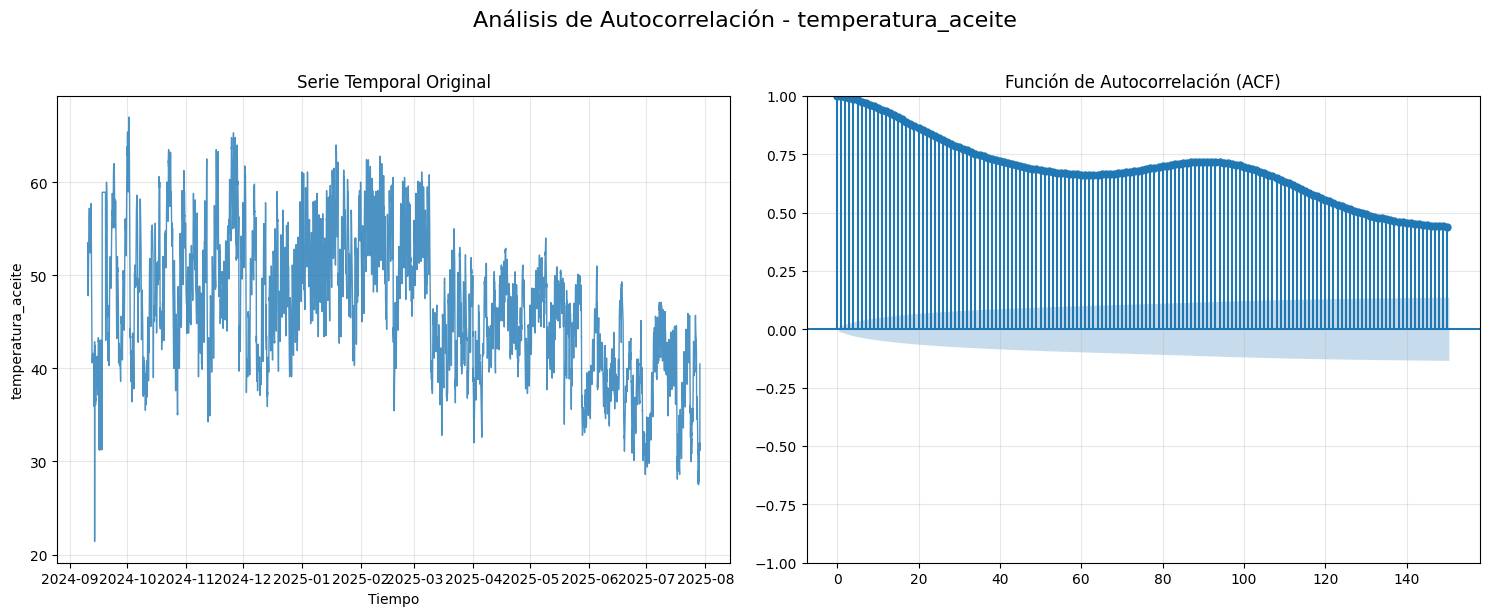


📊 ESTADÍSTICAS DE AUTOCORRELACIÓN - temperatura_aceite
Observaciones: 30912
Límite de confianza (95%): ±0.0111

🔍 Lags significativos en ACF:
  Lag 1: 0.9976
  Lag 2: 0.9943
  Lag 3: 0.9904
  Lag 4: 0.9858
  Lag 5: 0.9806
  Lag 6: 0.9750
  Lag 7: 0.9690
  Lag 8: 0.9627
  Lag 9: 0.9560
  Lag 10: 0.9488

📈 TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller):
Estadístico ADF: -8.341241
p-value: 0.000000
Valores críticos:
  1%: -3.430562
  5%: -2.861634
  10%: -2.566820
✅ La serie parece ser estacionaria (p-value ≤ 0.05)

ANÁLISIS DE AUTOCORRELACIÓN: VOLTAJE


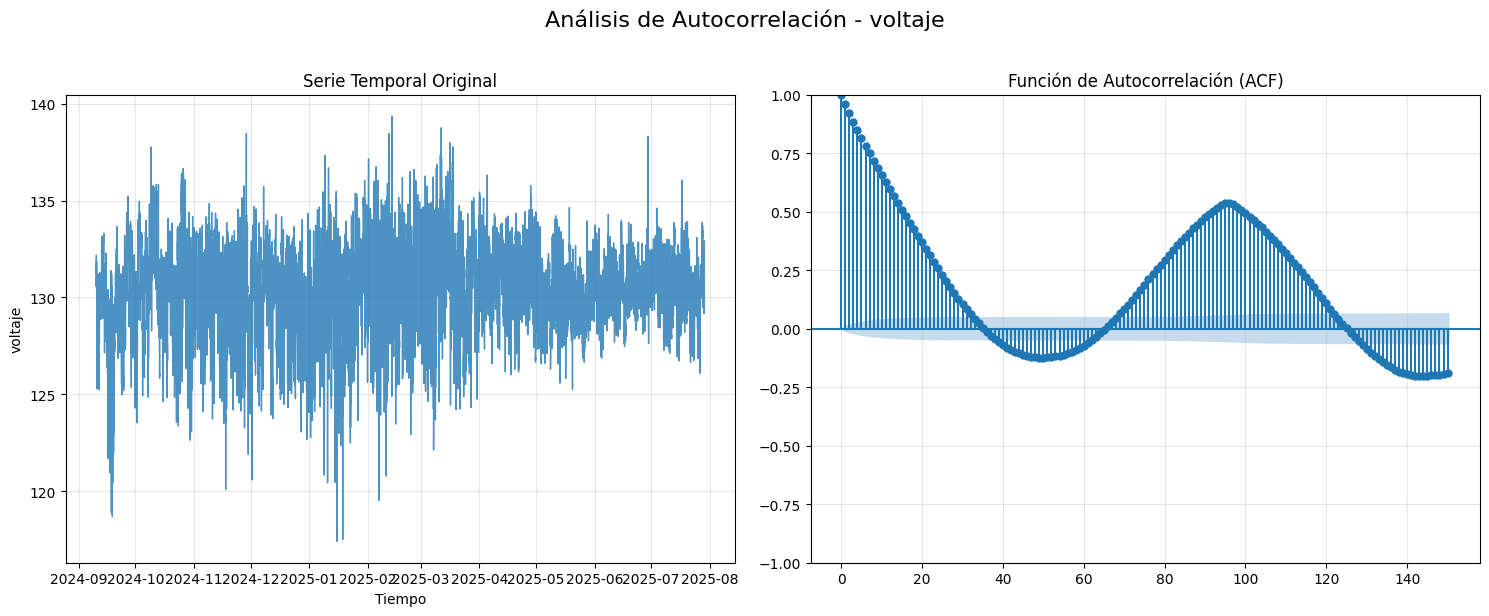


📊 ESTADÍSTICAS DE AUTOCORRELACIÓN - voltaje
Observaciones: 30912
Límite de confianza (95%): ±0.0111

🔍 Lags significativos en ACF:
  Lag 1: 0.9611
  Lag 2: 0.9221
  Lag 3: 0.8853
  Lag 4: 0.8501
  Lag 5: 0.8156
  Lag 6: 0.7826
  Lag 7: 0.7507
  Lag 8: 0.7190
  Lag 9: 0.6881
  Lag 10: 0.6565

📈 TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller):
Estadístico ADF: -21.754931
p-value: 0.000000
Valores críticos:
  1%: -3.430562
  5%: -2.861634
  10%: -2.566820
✅ La serie parece ser estacionaria (p-value ≤ 0.05)

ANÁLISIS DE AUTOCORRELACIÓN: CORRIENTE_CARGA


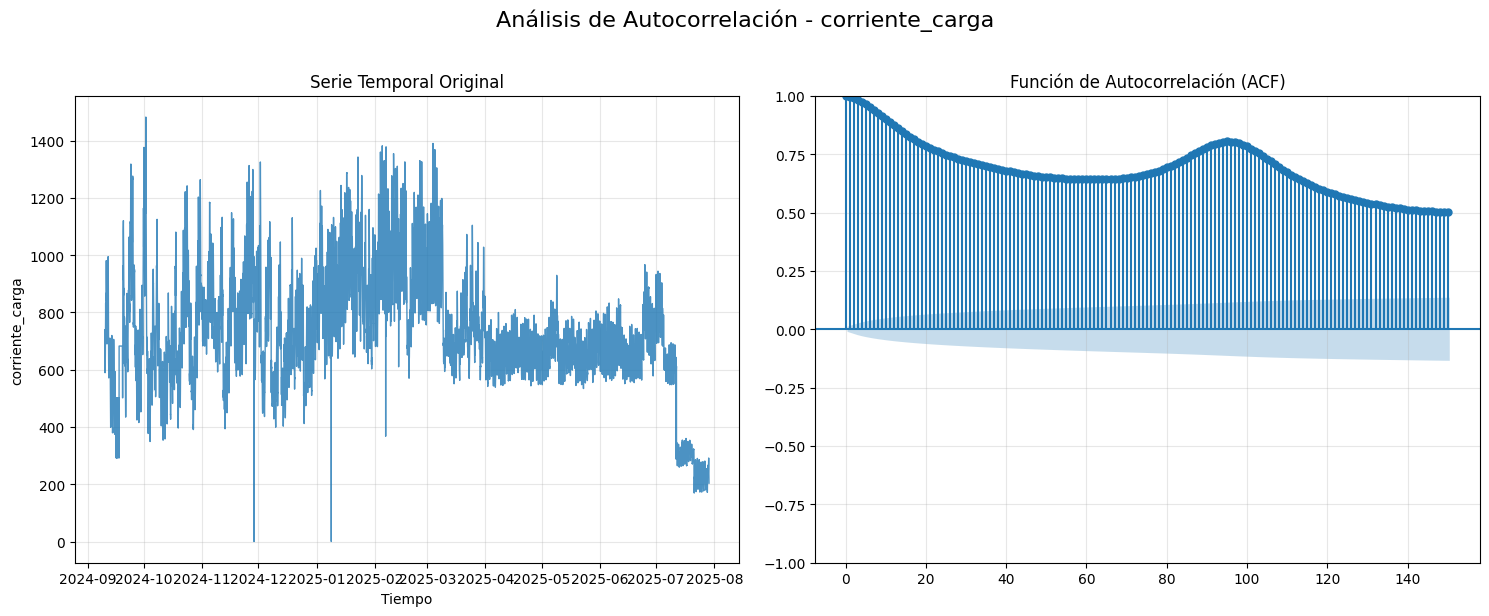


📊 ESTADÍSTICAS DE AUTOCORRELACIÓN - corriente_carga
Observaciones: 30912
Límite de confianza (95%): ±0.0111

🔍 Lags significativos en ACF:
  Lag 1: 0.9968
  Lag 2: 0.9911
  Lag 3: 0.9834
  Lag 4: 0.9743
  Lag 5: 0.9639
  Lag 6: 0.9525
  Lag 7: 0.9403
  Lag 8: 0.9275
  Lag 9: 0.9142
  Lag 10: 0.9007

📈 TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller):
Estadístico ADF: -8.107827
p-value: 0.000000
Valores críticos:
  1%: -3.430562
  5%: -2.861634
  10%: -2.566820
✅ La serie parece ser estacionaria (p-value ≤ 0.05)


In [6]:
#autocorrelacion del tiempo
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
def plot_autocorrelation(df, column, lags=200, figsize=(15, 6)):
    """
    Crea gráficos de autocorrelación para una serie temporal.
    
    Parámetros:
    - df: DataFrame con índice temporal
    - column: nombre de la columna a analizar
    - lags: número de lags a mostrar (por defecto 40)
    - figsize: tamaño de la figura
    """
    
    # Verificar que la columna existe
    if column not in df.columns:
        print(f"Error: La columna '{column}' no existe en el DataFrame")
        return
    
    # Obtener la serie y eliminar valores nulos
    serie = df[column].dropna()
    
    if len(serie) == 0:
        print(f"Error: No hay datos válidos en la columna '{column}'")
        return
    
    # Crear subplots - solo 2 gráficas
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'Análisis de Autocorrelación - {column}', fontsize=16, y=1.02)
    
    # 1. Serie temporal original
    axes[0].plot(serie.index, serie.values, linewidth=1, alpha=0.8)
    axes[0].set_title('Serie Temporal Original')
    axes[0].set_xlabel('Tiempo')
    axes[0].set_ylabel(column)
    axes[0].grid(True, alpha=0.3)
    
    # 2. Función de Autocorrelación (ACF)
    plot_acf(serie, lags=lags, ax=axes[1], alpha=0.05)
    axes[1].set_title('Función de Autocorrelación (ACF)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas adicionales
    print(f"\n📊 ESTADÍSTICAS DE AUTOCORRELACIÓN - {column}")
    print("=" * 60)
    
    # Calcular ACF y PACF valores
    acf_values = acf(serie, nlags=lags, fft=True)
    pacf_values = pacf(serie, nlags=lags)
    
    # Encontrar lags significativos
    significant_acf = []
    significant_pacf = []
    
    # Límite de confianza aproximado (95%)
    confidence_limit = 1.96 / np.sqrt(len(serie))
    
    for i in range(1, min(lags+1, len(acf_values))):
        if abs(acf_values[i]) > confidence_limit:
            significant_acf.append((i, acf_values[i]))
        if i < len(pacf_values) and abs(pacf_values[i]) > confidence_limit:
            significant_pacf.append((i, pacf_values[i]))
    
    print(f"Observaciones: {len(serie)}")
    print(f"Límite de confianza (95%): ±{confidence_limit:.4f}")
    
    if significant_acf:
        print(f"\n🔍 Lags significativos en ACF:")
        for lag, value in significant_acf[:10]:  # Mostrar los primeros 10
            print(f"  Lag {lag}: {value:.4f}")
    else:
        print("\n✅ No se encontraron autocorrelaciones significativas en ACF")
    
    # Test de estacionariedad (Augmented Dickey-Fuller)
    try:
        from statsmodels.tsa.stattools import adfuller
        
        adf_result = adfuller(serie.dropna())
        print(f"\n📈 TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller):")
        print(f"Estadístico ADF: {adf_result[0]:.6f}")
        print(f"p-value: {adf_result[1]:.6f}")
        print(f"Valores críticos:")
        for key, value in adf_result[4].items():
            print(f"  {key}: {value:.6f}")
        
        if adf_result[1] <= 0.05:
            print("✅ La serie parece ser estacionaria (p-value ≤ 0.05)")
        else:
            print("⚠️  La serie podría no ser estacionaria (p-value > 0.05)")
            
    except ImportError:
        print("\n⚠️  statsmodels no disponible para test de estacionariedad")


def plot_multiple_autocorrelations(df, columns, lags=40):
    """
    Crea gráficos de autocorrelación para múltiples variables.
    
    Parámetros:
    - df: DataFrame con índice temporal
    - columns: lista de nombres de columnas a analizar
    - lags: número de lags a mostrar
    """
    for col in columns:
        if col in df.columns:
            print(f"\n{'='*80}")
            print(f"ANÁLISIS DE AUTOCORRELACIÓN: {col.upper()}")
            print(f"{'='*80}")
            plot_autocorrelation(df, col, lags=lags)
        else:
            print(f"Columna '{col}' no encontrada en el DataFrame")

# Para múltiples variables
variables_temporales = ['temperatura_punto_caliente', 'temperatura_aceite', 'voltaje', 'corriente_carga']
plot_multiple_autocorrelations(df_gold, variables_temporales, lags=150)

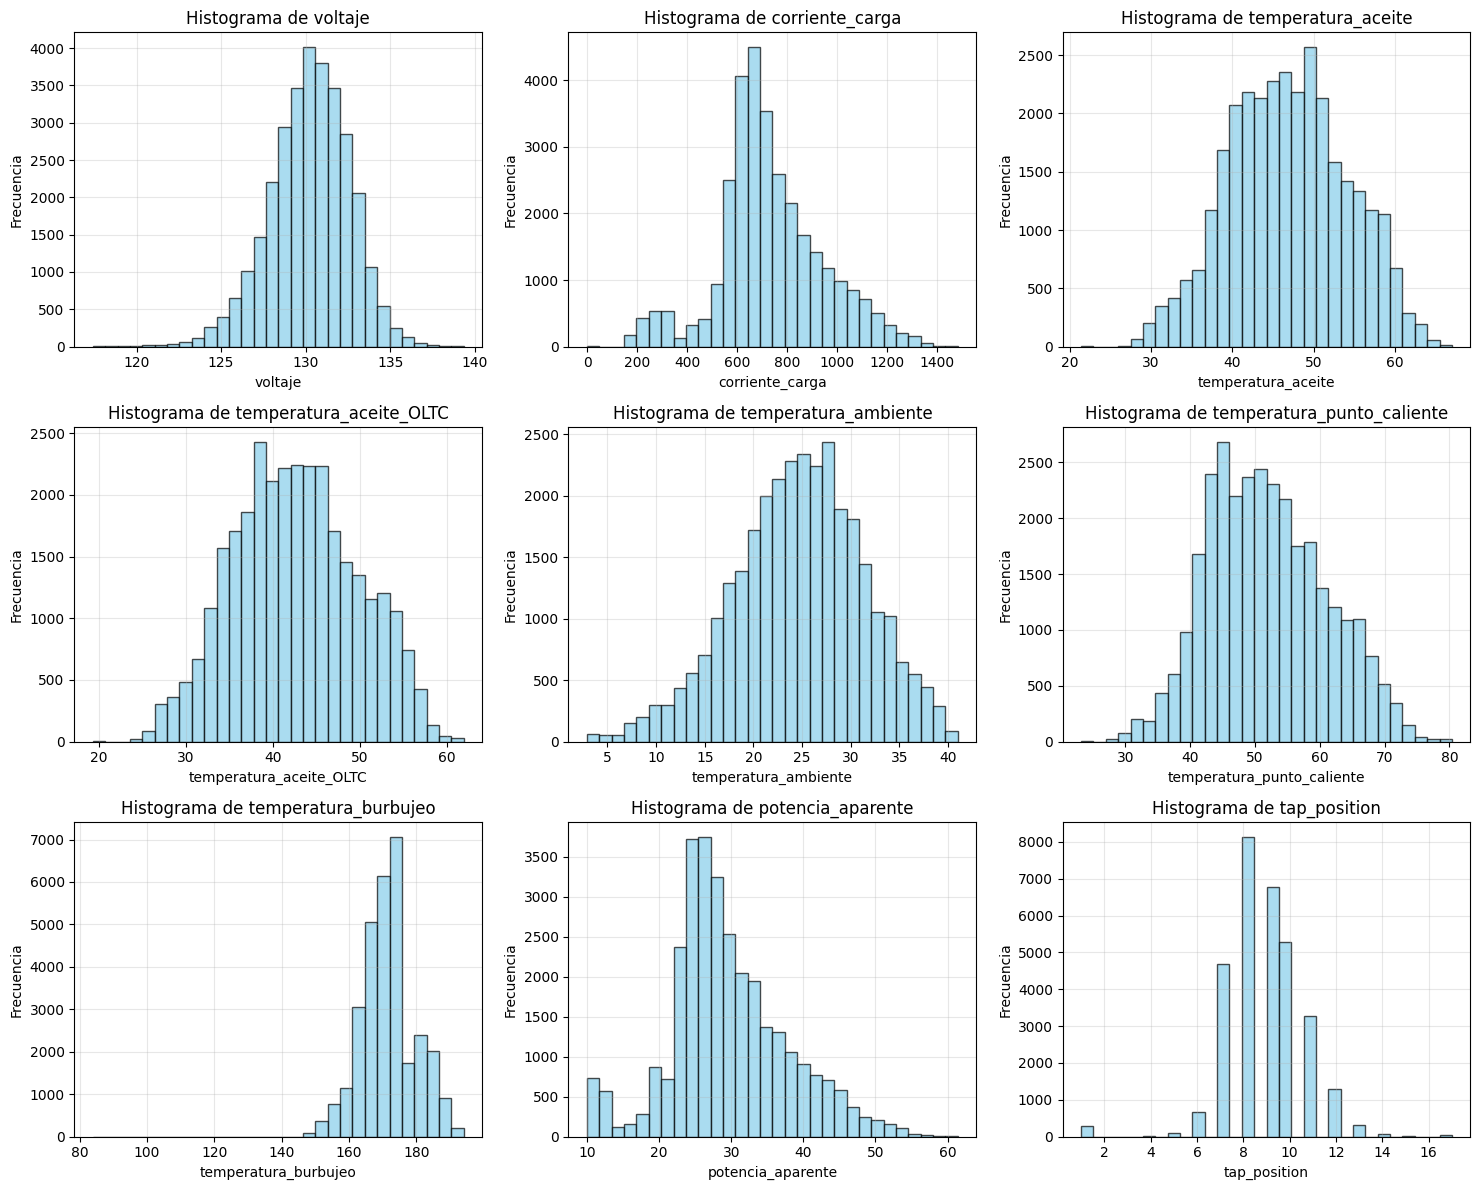

In [7]:
def plot_all_histograms(df, bins=30, color='skyblue', exclude_cols=None):
    """
    Grafica histogramas para todas las columnas numéricas del DataFrame en una grilla de 3 columnas.
    
    Parámetros:
    - df: DataFrame de pandas
    - bins: int, cantidad de bins (por defecto 30)
    - color: str, color del histograma
    - exclude_cols: lista de columnas a excluir (opcional)
    """
    import matplotlib.pyplot as plt
    import numpy as np

    if exclude_cols is None:
        exclude_cols = []

    numeric_cols = [col for col in df.select_dtypes(include=np.number).columns if col not in exclude_cols]
    n = len(numeric_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col].dropna(), bins=bins, color=color, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Histograma de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')
        axes[i].grid(True, alpha=0.3)

    # Ocultar ejes vacíos
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
plot_all_histograms(df_gold)

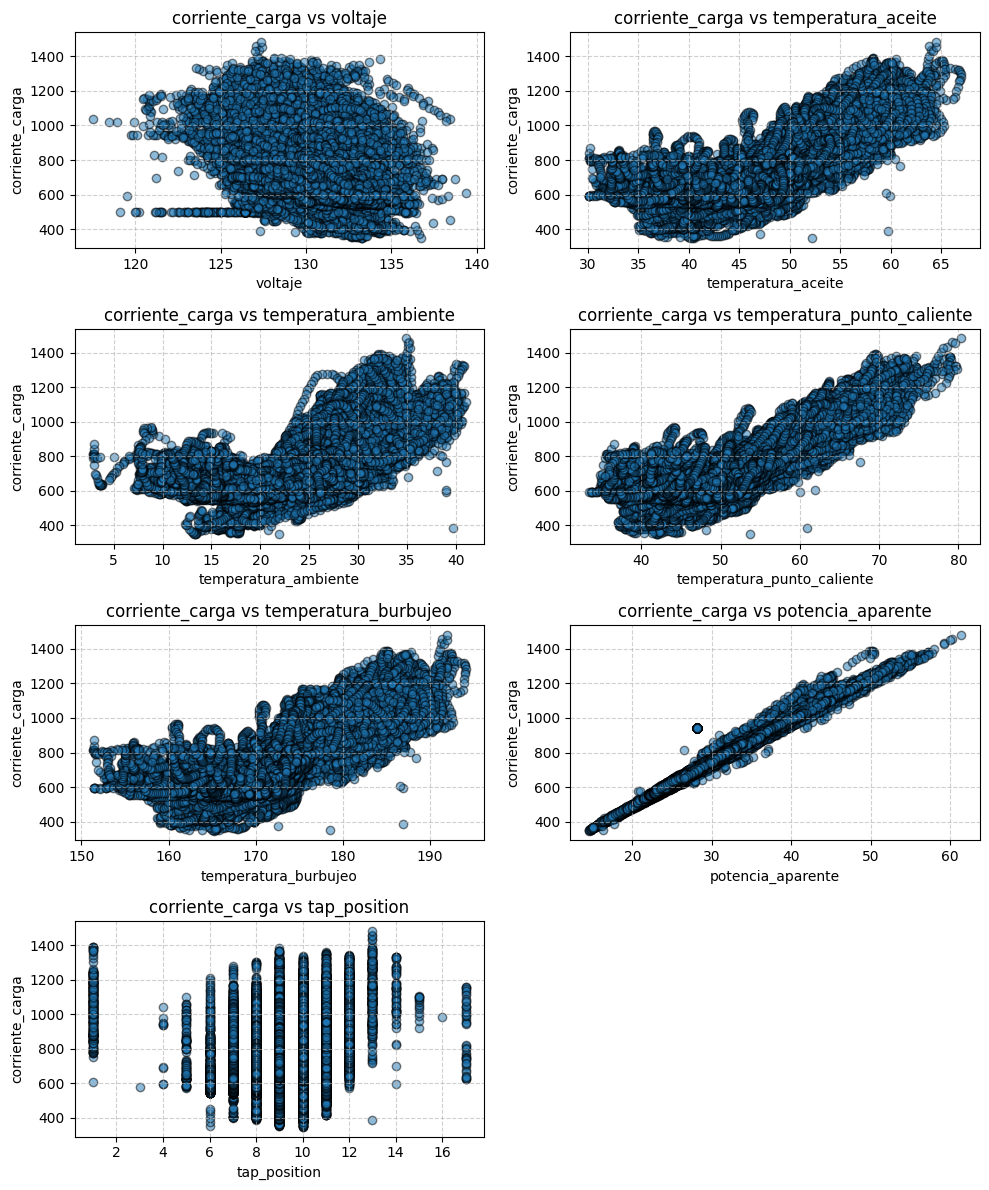

In [5]:
def plot_all_scatter(df, y, exclude_cols=["Timestamp"]):
    """
    Genera scatter plots de todas las columnas numéricas en `df` contra `y`.

    Parámetros:
    - df (DataFrame): El DataFrame con los datos.
    - y (str): La variable dependiente.
    - exclude_cols (list): Columnas a excluir en el análisis.
    """
    # Seleccionar variables numéricas excepto las excluidas y la variable objetivo
    variables_x = [col for col in df.columns if col not in exclude_cols + [y] and df[col].dtype != 'O']
    
    if not variables_x:
        print(" No hay variables numéricas para graficar.")
        return
    
    # Calcular número de filas de subplots
    filas = len(variables_x) // 2 + len(variables_x) % 2
    fig, axes = plt.subplots(filas, 2, figsize=(10, 3 * filas))
    axes = axes.flatten()

    for i, x in enumerate(variables_x):
        if df[[x, y]].dropna().empty:
            axes[i].text(0.5, 0.5, "Datos insuficientes", fontsize=12, ha='center', va='center')
            axes[i].set_title(f"{y} vs {x}")
            axes[i].axis("off")
            continue

        axes[i].scatter(df[x], df[y], alpha=0.5, edgecolors='k')
        axes[i].grid(True, linestyle="--", alpha=0.6)
        axes[i].set_title(f"{y} vs {x}")
        axes[i].set_xlabel(x)
        axes[i].set_ylabel(y)

    # Ocultar subplots vacíos
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
plot_all_scatter(df_gold, y="corriente_carga")


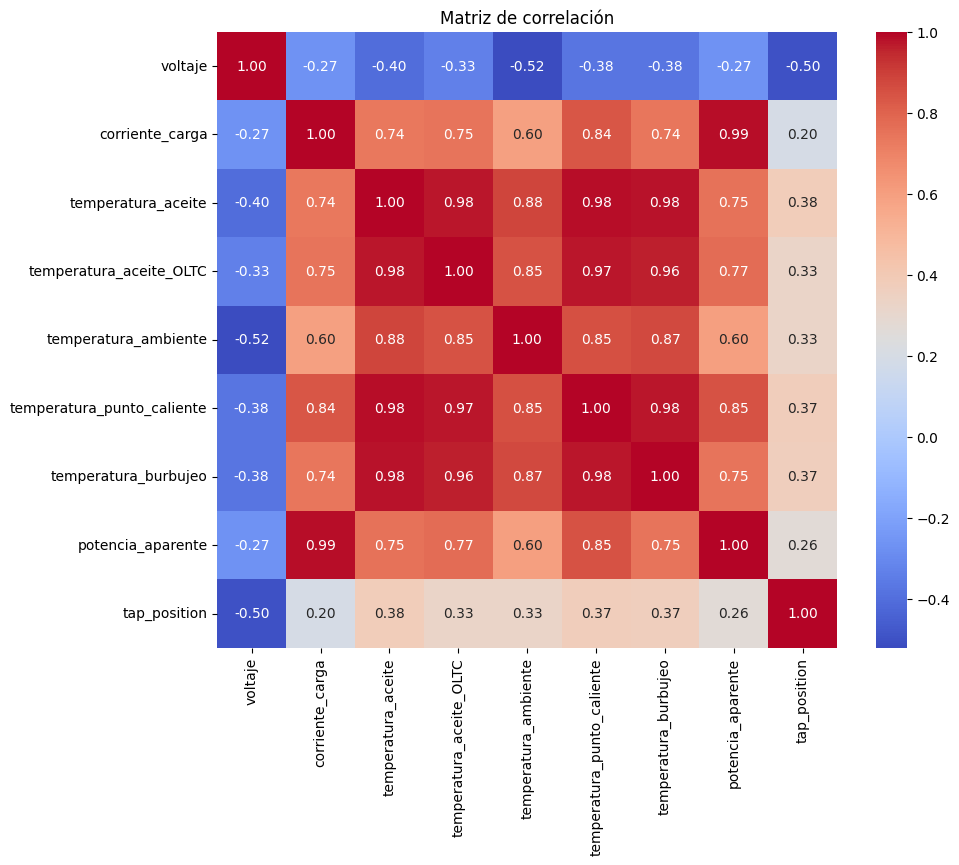

In [8]:
def heatMap(df):
    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Matriz de correlación")
    plt.show()
    
heatMap(df_gold)

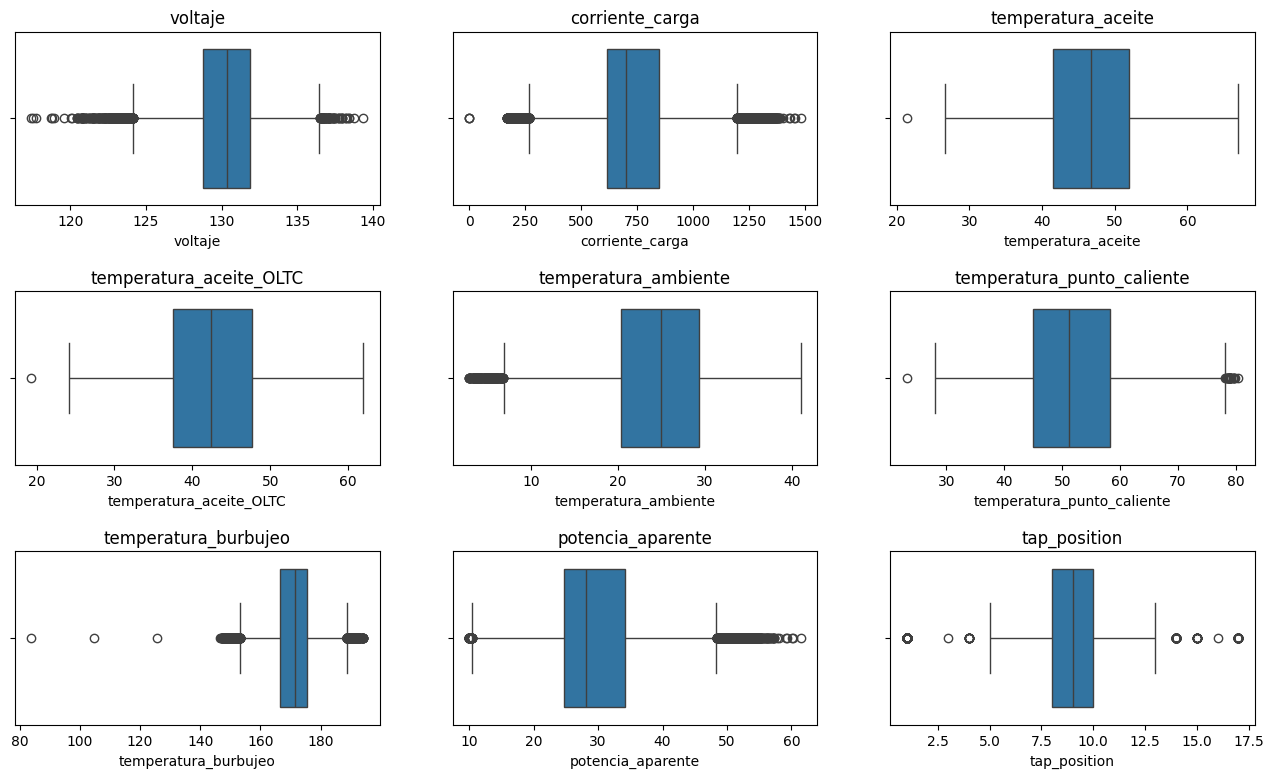

In [9]:
def boxplots(df):
    # Obtener las columnas numéricas
    cols_num = df.select_dtypes(include=['number']).columns.tolist()
    num_cols = 3  # Número de columnas en el subplot
    num_rows = (len(cols_num) + num_cols - 1) // num_cols
    
    # Crear subgráficos
    fig, ax = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 3 * num_rows))
    fig.subplots_adjust(hspace=0.5)
    ax = ax.flatten()
    
    # Generar gráficos individuales
    for i, col in enumerate(cols_num):
        sns.boxplot(x=df[col], ax=ax[i])
        ax[i].set_title(col)
    
    # Ocultar subplots vacíos si hay un número impar de gráficos
    for j in range(i + 1, len(ax)):
        fig.delaxes(ax[j])
    plt.show()
boxplots(df_gold)

In [3]:
def estadisticas_por_variable(df, exclude_cols=None):
    """
    Genera estadísticas descriptivas detalladas para cada variable numérica del DataFrame.
    
    Parámetros:
    - df: DataFrame de pandas
    - exclude_cols: lista de columnas a excluir (opcional)
    """
    if exclude_cols is None:
        exclude_cols = []
    
    # Seleccionar solo columnas numéricas
    numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                   if col not in exclude_cols]
    
    estadisticas = []
    
    for col in numeric_cols:
        serie = df[col]
        datos_limpios = serie.dropna()
        
        if len(datos_limpios) > 0:
            stats = {
                'Variable': col,
                'Count': len(serie),
                'Non_Null': len(datos_limpios),
                'Mean': datos_limpios.mean(),
                'Median': datos_limpios.median(),
                'Mode': datos_limpios.mode().iloc[0] if not datos_limpios.mode().empty else np.nan,
                'Std': datos_limpios.std(),
                'Variance': datos_limpios.var(),
                'Min': datos_limpios.min(),
                'Q1': datos_limpios.quantile(0.25),
                'Q3': datos_limpios.quantile(0.75),
                'Max': datos_limpios.max(),
                'Range': datos_limpios.max() - datos_limpios.min(),
                'IQR': datos_limpios.quantile(0.75) - datos_limpios.quantile(0.25),
                'Skewness': datos_limpios.skew(),
                'Kurtosis': datos_limpios.kurtosis(),

            }
            estadisticas.append(stats)
    
    # Crear DataFrame con las estadísticas
    df_stats = pd.DataFrame(estadisticas)
    
    # Redondear valores numéricos para mejor presentación
    columnas_numericas = ['Mean', 'Median', 'Mode', 'Std', 'Variance', 'Min', 'Q1', 'Q3', 'Max', 
                         'Range', 'IQR', 'Skewness', 'Kurtosis']
    
    for col in columnas_numericas:
        if col in df_stats.columns:
            df_stats[col] = df_stats[col].round(4)
        
    return df_stats
# Ejecutar análisis
print(" Generando estadísticas por variable...")
stats_detalladas = estadisticas_por_variable(df_gold)

# Mostrar tabla completa
print("\n📋 TABLA COMPLETA DE ESTADÍSTICAS:")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(stats_detalladas.to_string(index=False))

 Generando estadísticas por variable...

📋 TABLA COMPLETA DE ESTADÍSTICAS:
                  Variable  Count  Non_Null     Mean   Median     Mode      Std   Variance      Min       Q1       Q3       Max     Range      IQR  Skewness  Kurtosis
                   voltaje  30912     30912 130.2396 130.3629 126.4099   2.3515     5.5298 117.4178 128.7684 131.8570  139.3534   21.9356   3.0886   -0.3556    0.4805
           corriente_carga  30912     30912 731.2062 702.0090 682.4350 209.3623 43832.5605   0.0000 616.3155 848.7475 1481.9821 1481.9821 232.4320    0.1564    0.5176
        temperatura_aceite  30912     30912  46.8919  46.7941  43.0000   7.2457    52.4994  21.4000  41.5634  51.9718   67.0000   45.6000  10.4084    0.0056   -0.5221
   temperatura_aceite_OLTC  30912     30912  42.6038  42.4000  39.0000   7.0585    49.8226  19.3500  37.4764  47.6000   61.9000   42.5500  10.1236    0.0668   -0.5905
      temperatura_ambiente  30912     30912  24.6762  24.9500  25.3000   6.7018    44.9142

In [4]:
import numpy as np
import pandas as pd
from scipy import stats

class BoxCoxTransformer:
    """
    Aplica Box–Cox a columnas continuas y positivas.
    - Si la columna tiene valores <= 0, aplica un shift: x' = x + |min| + eps.
    - Guarda lambda y shift por columna para poder invertir.
    """

    def __init__(self, eps=1e-6):
        self.eps = eps
        self.lambdas_ = {}  # {col: lambda}
        self.shifts_  = {}  # {col: shift añadido}

    def fit_transform(self, df: pd.DataFrame, cols: list) -> pd.DataFrame:
        df_out = df.copy()
        for col in cols:
            x = df_out[col].astype(float).to_numpy()

            # Shift si hay valores <= 0
            shift = 0.0
            x_min = np.nanmin(x)
            if not np.isfinite(x_min):
                raise ValueError(f"{col}: todos los valores son NaN/inf; revise la columna.")
            if x_min <= 0:
                shift = -x_min + self.eps
                x = x + shift

            # Relleno temporal de NaNs para el ajuste del lambda (Box-Cox no admite NaN)
            # Usamos media de la serie (solo para el ajuste); luego reponemos NaN en el resultado.
            nan_mask = np.isnan(x)
            if nan_mask.any():
                mean_val = np.nanmean(x)
                x_for_fit = x.copy()
                x_for_fit[nan_mask] = mean_val
            else:
                x_for_fit = x

            # Ajuste y transformación
            x_bc, lam = stats.boxcox(x_for_fit)
            # Reponer NaNs en las posiciones originales
            x_bc[nan_mask] = np.nan

            # Persistir en el DataFrame
            df_out[col] = x_bc

            # Guardar parámetros
            self.lambdas_[col] = lam
            self.shifts_[col]  = shift

        return df_out

    def inverse_transform(self, df: pd.DataFrame, cols: list) -> pd.DataFrame:
        df_inv = df.copy()
        for col in cols:
            if col not in self.lambdas_:
                raise ValueError(f"No hay lambda para la columna '{col}'. Ejecute fit_transform primero.")
            lam   = self.lambdas_[col]
            shift = self.shifts_.get(col, 0.0)

            y = df_inv[col].astype(float).to_numpy()
            nan_mask = np.isnan(y)

            # Inversa de Box–Cox:  y = (lam * x_bc + 1) ** (1/lam)  si lam != 0
            #                       exp(x_bc)                      si lam == 0
            if lam == 0:
                x = np.exp(y)
            else:
                x = np.power(lam * y + 1.0, 1.0 / lam)

            # Quitar shift
            x = x - shift
            x[nan_mask] = np.nan
            df_inv[col] = x
        return df_inv

    def report_skew_kurt(self, df_before: pd.DataFrame, df_after: pd.DataFrame, cols: list) -> pd.DataFrame:
        rows = []
        for col in cols:
            b = df_before[col].dropna().astype(float)
            a = df_after[col].dropna().astype(float)
            rows.append({
                "columna": col,
                "lambda": self.lambdas_.get(col),
                "shift":  self.shifts_.get(col, 0.0),
                "skew_before": stats.skew(b),
                "kurt_before": stats.kurtosis(b),
                "skew_after":  stats.skew(a),
                "kurt_after":  stats.kurtosis(a),
            })
        return pd.DataFrame(rows)


In [5]:
# columnas a transformar según tu análisis
cols_bc = ["corriente_carga", "temperatura_burbujeo","potencia_aparente"]

# 1) Ajuste + transformación
bc = BoxCoxTransformer(eps=1e-6)
df_gold_bc = bc.fit_transform(df_gold, cols_bc)

# 2) Validación estadística
reporte = bc.report_skew_kurt(df_gold, df_gold_bc, cols_bc)
print(reporte)


                columna    lambda     shift  skew_before  kurt_before  \
0       corriente_carga  0.907248  0.000001     0.156357     0.517290   
1  temperatura_burbujeo  0.931318  0.000000     0.027099     0.658700   
2     potencia_aparente  0.699280  0.000000     0.360123     0.461319   

   skew_after  kurt_after  
0    0.044767    0.568454  
1    0.013580    0.715418  
2    0.038801    0.521966  


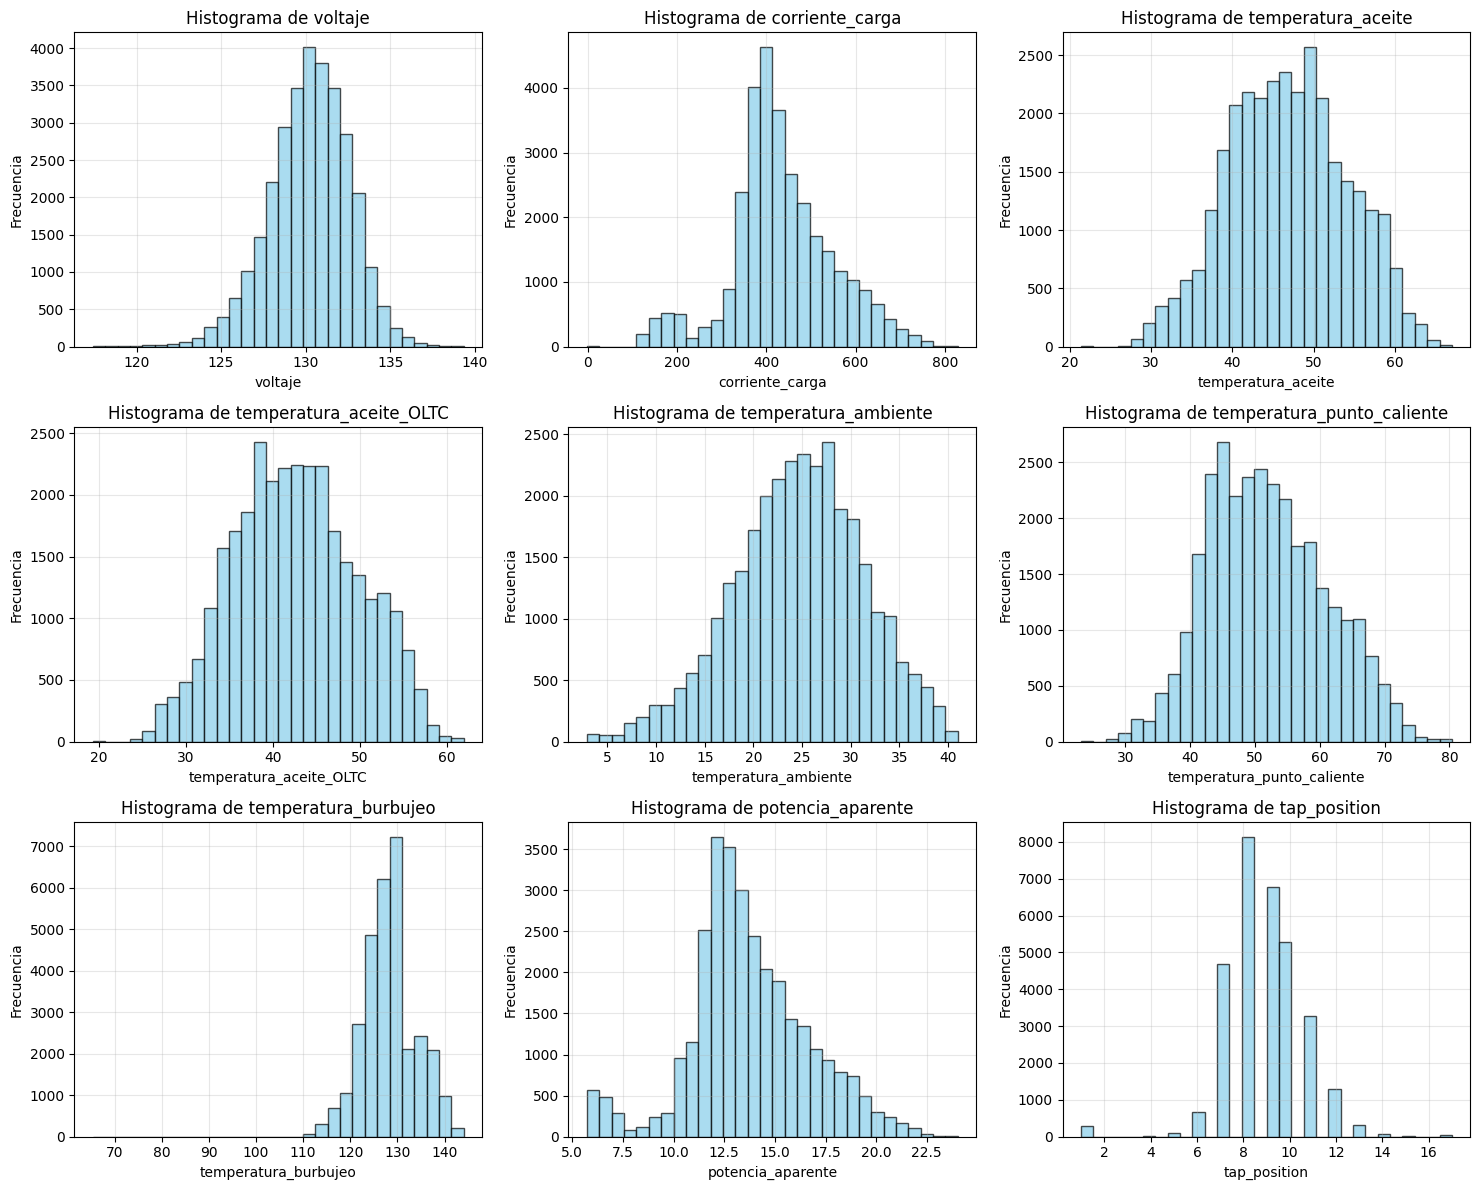

In [8]:
plot_all_histograms(df_gold_bc)

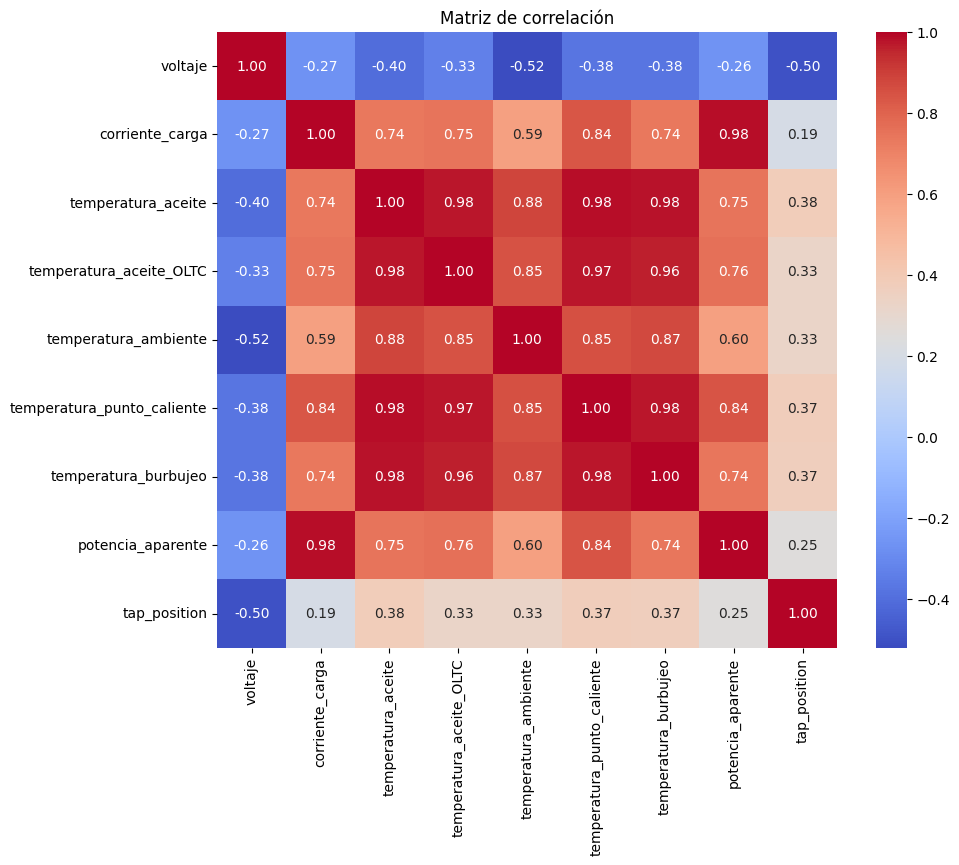

In [13]:
heatMap(df_gold_bc)

In [23]:
df_copy=df_gold_bc.copy()
df_copy["gradiente_termico"] = df_copy["temperatura_aceite"] - df_copy["temperatura_ambiente"]
df_copy["hour"] = df_copy.index.hour
df_copy["dia_semana"] = df_copy.index.dayofweek
df_copy["mes"] = df_copy.index.month
df_copy["is_weekend"] = (df_copy.index.dayofweek >= 5).astype(int)
#FEATURE ENGINEERING PARA LA VARIABLE CON TEMPERATURA ACEITE OLTC


In [25]:
df_copy.dropna(inplace=True) # ¡Precaución! Evalúa si 0 es un valor

In [24]:
cols_to_drop_for_multicollinearity = [
    'corriente_carga',  # Alta correlación con corriente_carga
    'temperatura_aceite',
    'temperatura_aceite_OLTC',
    'temperatura_burbujeo'
]

# Asegurarse de que las columnas existan antes de intentar eliminarlas
existing_cols_to_drop = [col for col in cols_to_drop_for_multicollinearity if col in df_copy.columns]

df_copy = df_copy.drop(columns=existing_cols_to_drop)
print(f"Columnas eliminadas por multicolinealidad: {existing_cols_to_drop}")
print(display(df_copy.head()))

Columnas eliminadas por multicolinealidad: ['corriente_carga', 'temperatura_aceite', 'temperatura_aceite_OLTC', 'temperatura_burbujeo']


,voltaje,temperatura_ambiente,temperatura_punto_caliente,potencia_aparente,tap_position,gradiente_termico,hour,dia_semana,mes,is_weekend
timestamp,,,,,,,,,,
2024-09-10 04:00:00,131.041825,26.500000,56.185879,14.263727,10,25.034286,4,1,9,0
2024-09-10 04:15:00,130.693073,26.650000,58.642727,14.080147,11,26.850000,4,1,9,0
2024-09-10 04:30:00,130.812457,26.800000,58.308074,13.897779,11,26.542857,4,1,9,0
2024-09-10 04:45:00,130.924854,26.600000,57.973421,13.694917,11,26.585714,4,1,9,0
2024-09-10 05:00:00,130.564417,26.233334,57.638768,13.493419,11,26.795238,5,1,9,0


None


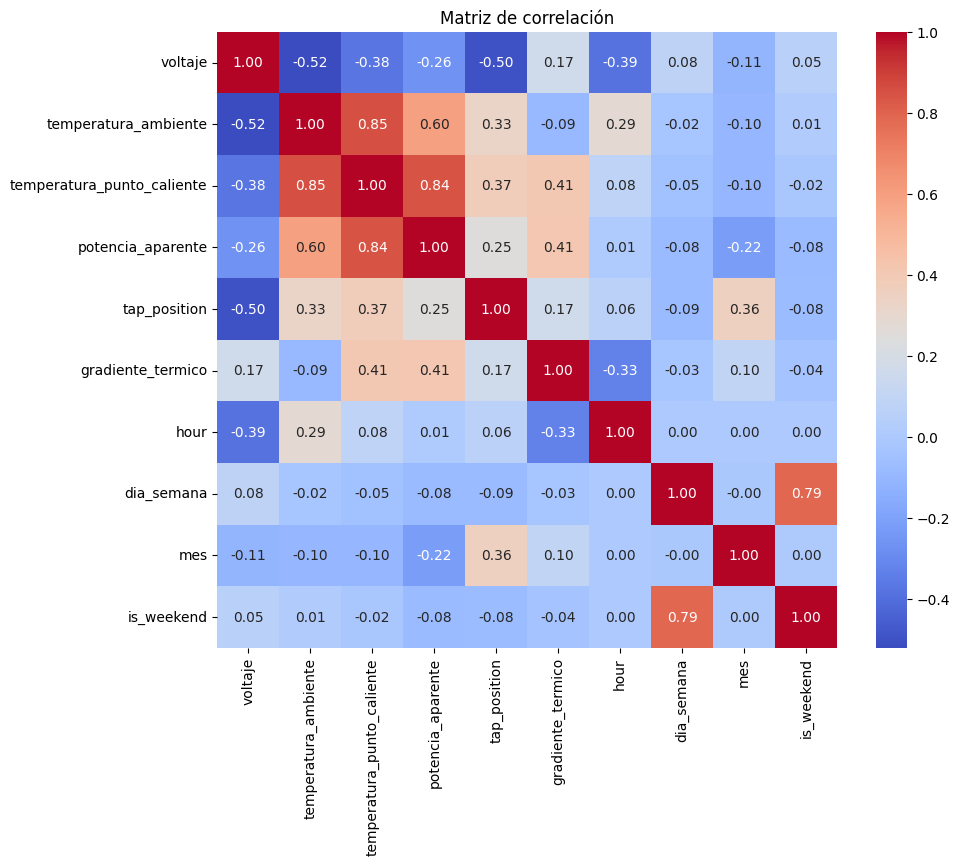

In [26]:
heatMap(df_copy)

In [29]:
from sklearn.preprocessing import RobustScaler
import pandas as pd
# split_index = int(len(df_copy) * 0.8)
# df_train = df_copy[:split_index]
# df_test = df_copy[split_index:]
# print(f"Datos de entrenamiento: {df_train.shape}")
# print(f"Datos de prueba: {df_test.shape}")




In [27]:
total_len = len(df_copy)
train_start = int(total_len * 0.4)
train_end = int(total_len * 0.6)

# X_train: 20% del medio
df_test = df_copy[train_start:train_end]

# X_test: 40% del inicio + 40% del final
df_train = pd.concat([df_copy[:train_start], df_copy[train_end:]], axis=0)

print(f"Datos de entrenamiento: {df_train.shape}")
print(f"Datos de prueba: {df_test.shape}")


Datos de entrenamiento: (24729, 10)
Datos de prueba: (6183, 10)


In [28]:
def aplicar_robust_scaler_train_test(df_train, df_test, columnas):
    scaler = RobustScaler()
    
    # Entrenar el scaler SOLO con datos de entrenamiento
    scaler.fit(df_train[columnas])
    
    # Aplicar transformación a ambos conjuntos
    df_train_scaled = df_train.copy()
    df_test_scaled = df_test.copy()
    
    df_train_scaled[columnas] = scaler.transform(df_train[columnas])
    df_test_scaled[columnas] = scaler.transform(df_test[columnas])
    
    return df_train_scaled, df_test_scaled, scaler

# Aplicar escalado
columnas_a_escalar = [
    'voltaje',
    'temperatura_ambiente', 'temperatura_punto_caliente',
 'potencia_aparente', 'gradiente_termico', 'hour', 'dia_semana', 'mes', 'is_weekend'
]

df_train_scaled, df_test_scaled, scaler = aplicar_robust_scaler_train_test(
    df_train, df_test, columnas_a_escalar
)

print("Datos de entrenamiento escalados:")
print(df_train_scaled[columnas_a_escalar].head())
print("\nDatos de prueba escalados:")
print(df_test_scaled[columnas_a_escalar].head())

# Verificar que las escalas son consistentes
print(f"\nEstadísticas del conjunto de entrenamiento escalado:")
print(df_train_scaled[columnas_a_escalar].describe())
print(f"\nEstadísticas del conjunto de prueba escalado:")
print(df_test_scaled[columnas_a_escalar].describe())

Datos de entrenamiento escalados:
                      voltaje  temperatura_ambiente  \
timestamp                                             
2024-09-10 04:00:00  0.245521              0.331338   
2024-09-10 04:15:00  0.127349              0.348477   
2024-09-10 04:30:00  0.167801              0.365615   
2024-09-10 04:45:00  0.205886              0.342764   
2024-09-10 05:00:00  0.083755              0.300870   

                     temperatura_punto_caliente  potencia_aparente  \
timestamp                                                            
2024-09-10 04:00:00                    0.572902           0.490691   
2024-09-10 04:15:00                    0.786503           0.425153   
2024-09-10 04:30:00                    0.757408           0.360048   
2024-09-10 04:45:00                    0.728313           0.287627   
2024-09-10 05:00:00                    0.699218           0.215692   

                     gradiente_termico      hour  dia_semana  mes  is_weekend  
timestamp

In [2]:
#unir los datos de trained y test
import pandas as pd
df_last = pd.concat([df_train_scaled, df_test_scaled], axis=0)
#guardar como archivo parquet
df_last.shape

NameError: name 'df_train_scaled' is not defined

In [29]:
X_train = df_train_scaled.drop(columns=['temperatura_punto_caliente'])
y_train = df_train_scaled['temperatura_punto_caliente']
X_test = df_test_scaled.drop(columns=['temperatura_punto_caliente'])
y_test = df_test_scaled['temperatura_punto_caliente']

In [41]:
from xgboost import XGBRegressor
import xgboost as xgb

estimators = 200

# Crear el modelo XGBoost para regresión
params = { 
    "n_estimators":estimators,
    "learning_rate":0.05,
    "gamma": 0.3,
    "min_child_weight": 5,
    "max_depth": 2,
    "subsample": 0.7,
    "colsample_bytree": 0.9,
    "objective": 'reg:squarederror',
    "random_state": 42,
    "n_jobs": 3
}

model = xgb.XGBRegressor(**params)
# Ver la configuración por defecto
print(model.get_params())


{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.3, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 2, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': 3, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.7, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [34]:
from sklearn.model_selection import GridSearchCV

# Definir los parámetros a ajustar
param_grid = {
    'n_estimators': [100,150, 200,250],
    'learning_rate': [0.01,0.03,0.04, 0.05,0.07, 1],
    'min_child_weight' : [5, 7],
    'max_depth': [2, 3, 4],
    'subsample': [0.4, 0.3, 0.5,0.7], 
    'gamma' : [0.3, 0.6, 0.8, 1],
}
# Crear el modelo para GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')

# Entrenar con GridSearchCV
grid_search.fit(X_train, y_train)

# Ver los mejores parámetros encontrados
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'gamma': 0.3, 'learning_rate': 1, 'max_depth': 2, 'min_child_weight': 7, 'n_estimators': 200, 'subsample': 0.5}


In [ ]:
# # #grid search
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform, randint

# param_dist = {
#     'n_estimators': randint(100, 400),
#     'max_depth': randint(2, 8),
#     'learning_rate': uniform(0.005, 0.1),
#     'gamma': uniform(0, 2),
#     'min_child_weight': randint(1, 10),
#     'subsample': uniform(0.5, 0.5),
#     'colsample_bytree': uniform(0.5, 0.5)
# }

# random_search = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=param_dist,
#     scoring='neg_mean_absolute_error',
#     n_iter=50,
#     cv=3,
#     random_state=42,
#     n_jobs=-1
# )

# random_search.fit(X_train, y_train)
# print("Best parameters:", random_search.best_params_)

Best parameters: {'colsample_bytree': np.float64(0.9692763545078751), 'gamma': np.float64(0.0015575316820286567), 'learning_rate': np.float64(0.10422115592912176), 'max_depth': 2, 'min_child_weight': 6, 'n_estimators': 352, 'subsample': np.float64(0.7159725093210578)}


In [31]:
def train_and_evaluate_xgboost(model, X_train, y_train, X_test, y_test, max_estimators=200):
    """
    Entrena un modelo XGBoost variando el número de estimadores y guarda las métricas.

    Retorna:
    - train_losses: lista con las pérdidas de entrenamiento
    - test_losses: lista con las pérdidas de prueba
    - test_accuracies: lista con las precisiones de prueba (R² en regresión)
    """
    train_accuracies = []
    train_losses = []
    test_losses = []
    test_accuracies = []

    for n_estimators in range(1, max_estimators + 1):
        model.set_params(n_estimators=n_estimators)
        model.fit(X_train, y_train)

        # Predicciones
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Calcular métricas
        train_accuracy = r2_score(y_train, y_train_pred)
        train_loss = mean_absolute_error(y_train, y_train_pred)
        test_loss = mean_absolute_error(y_test, y_test_pred)
        test_accuracy = r2_score(y_test, y_test_pred)

        # Guardar métricas
        train_accuracies.append(train_accuracy)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        # Imprimir progreso
        print(f"Estimators: {n_estimators}/{max_estimators}.. Tr MAE: {train_loss:.3f}.. Test MAE: {test_loss:.3f}.. tr R²: {train_accuracy:.3f}.. Test R²: {test_accuracy:.3f}")

    return train_losses, test_losses, test_accuracies, train_accuracies

def plot_training_metrics(train_losses, test_losses, test_accuracies, train_accuracies, max_estimators=200):
    """
    Grafica las métricas de entrenamiento y prueba obtenidas.

    """

    plt.figure(figsize=(8, 3))

    # Gráfica de pérdida
    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_estimators + 1), train_losses, label='Training Loss')
    plt.plot(range(1, max_estimators + 1), test_losses, label='Test Loss')
    plt.xlabel("Estimators")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and Test Loss")

    # Gráfica de precisión (R²)
    plt.subplot(1, 2, 2)
    plt.plot(range(1, max_estimators + 1), test_accuracies, label='Test Accuracy (R²)', color='orange')
    plt.plot(range(1, max_estimators + 1), train_accuracies, label='Test Accuracy (R²)', color='blue')
    plt.xlabel("Estimators")
    plt.ylabel("Accuracy (R²)")
    plt.legend()
    plt.title("Test Accuracy (R²)")

    plt.tight_layout()
    plt.show()

def plot_test_predictions(y_test, y_test_pred):
    """
    Grafica las predicciones vs valores reales y los residuos en el conjunto de prueba.

    """

    # Gráfico de dispersión: Predicciones vs Valores Reales
    plt.figure(figsize=(8, 3))
    plt.scatter(y_test, y_test_pred, color='blue', alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal (y = x)')
    plt.xlabel("Real Values")
    plt.ylabel("Predicted Values")
    plt.title("Predictions vs Real Values (Test Set)")
    plt.legend()
    plt.show()

    # Gráfico de residuos
    residuals = y_test - y_test_pred
    plt.figure(figsize=(8, 4))
    plt.scatter(y_test, residuals, color='green', alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel("Real Values")
    plt.ylabel("Residuals (Error)")
    plt.title("Residuals vs Real Values (Test Set)")
    plt.show()

Estimators: 1/200.. Tr MAE: 0.571.. Test MAE: 0.808.. tr R²: 0.072.. Test R²: -0.787
Estimators: 2/200.. Tr MAE: 0.549.. Test MAE: 0.773.. tr R²: 0.136.. Test R²: -0.647
Estimators: 3/200.. Tr MAE: 0.529.. Test MAE: 0.738.. tr R²: 0.195.. Test R²: -0.509
Estimators: 4/200.. Tr MAE: 0.509.. Test MAE: 0.705.. tr R²: 0.248.. Test R²: -0.392
Estimators: 5/200.. Tr MAE: 0.491.. Test MAE: 0.676.. tr R²: 0.298.. Test R²: -0.295
Estimators: 6/200.. Tr MAE: 0.474.. Test MAE: 0.647.. tr R²: 0.342.. Test R²: -0.192
Estimators: 7/200.. Tr MAE: 0.458.. Test MAE: 0.619.. tr R²: 0.382.. Test R²: -0.097
Estimators: 8/200.. Tr MAE: 0.443.. Test MAE: 0.593.. tr R²: 0.419.. Test R²: -0.019
Estimators: 9/200.. Tr MAE: 0.428.. Test MAE: 0.570.. tr R²: 0.454.. Test R²: 0.045
Estimators: 10/200.. Tr MAE: 0.415.. Test MAE: 0.545.. tr R²: 0.485.. Test R²: 0.123
Estimators: 11/200.. Tr MAE: 0.405.. Test MAE: 0.521.. tr R²: 0.512.. Test R²: 0.197
Estimators: 12/200.. Tr MAE: 0.391.. Test MAE: 0.501.. tr R²: 0.54

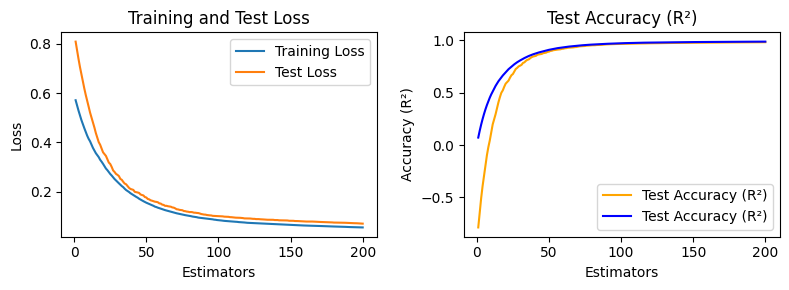

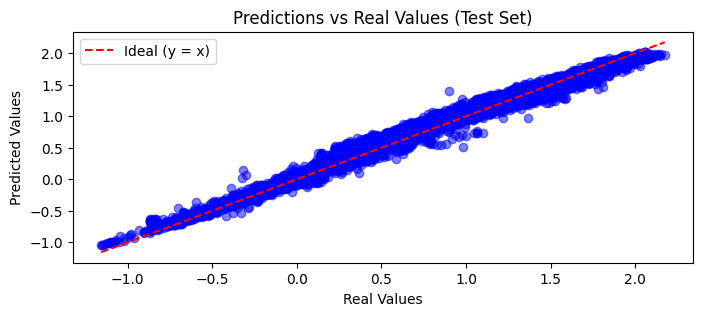

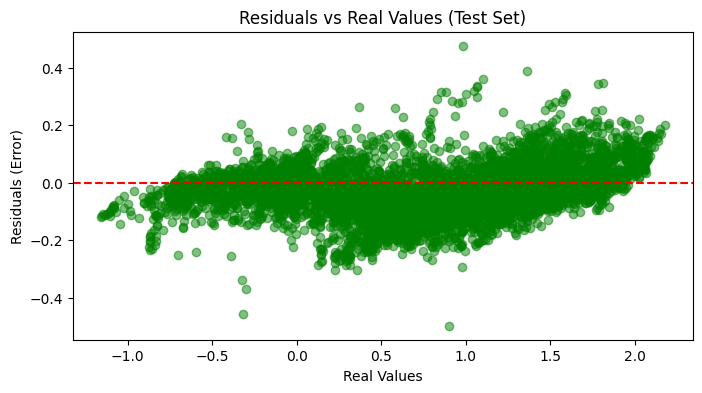

In [42]:
# Entrenar y obtener métricas
train_losses, test_losses, test_accuracies, train_accuracies = train_and_evaluate_xgboost(model, X_train, y_train, X_test, y_test, max_estimators=estimators)

# Graficar métricas
plot_training_metrics(train_losses, test_losses, test_accuracies, train_accuracies, max_estimators=estimators)

# Hacer predicciones en el conjunto de prueba
y_test_pred = model.predict(X_test)

# Graficar predicciones vs reales
plot_test_predictions(y_test, y_test_pred)

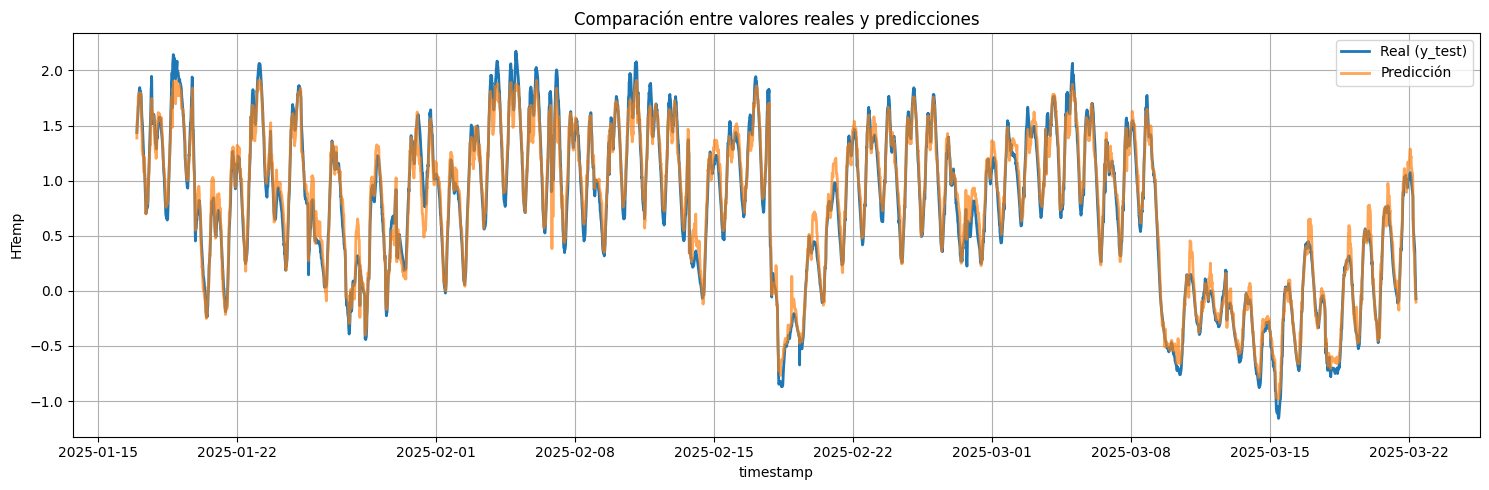

In [40]:
# Crear la figura
plt.figure(figsize=(15, 5))
plt.plot(y_test, label="Real (y_test)", linewidth=2)
plt.plot(y_test.index, y_test_pred, label="Predicción", linewidth=2, alpha=0.7)
plt.title("Comparación entre valores reales y predicciones")
plt.xlabel("timestamp")
plt.ylabel("HTemp")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
#comparacion de modelos
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import mean_absolute_error, r2_score
param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(2, 8),
    'learning_rate': uniform(0.005, 0.1),
    'gamma': uniform(0, 2),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5)
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    scoring='neg_mean_absolute_error',
    n_iter=50,
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
best_params = random_search.best_params_
modelos = {
    "XGBoost": xgb.XGBRegressor(**best_params),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=7, random_state=42),
}

resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({"Modelo": nombre, "MAE": mae, "R²": r2})

df_resultados = pd.DataFrame(resultados).sort_values(by="MAE")
print(df_resultados)


Best parameters: {'colsample_bytree': np.float64(0.9692763545078751), 'gamma': np.float64(0.0015575316820286567), 'learning_rate': np.float64(0.10422115592912176), 'max_depth': 2, 'min_child_weight': 6, 'n_estimators': 352, 'subsample': np.float64(0.7159725093210578)}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1075
[LightGBM] [Info] Number of data points in the train set: 22503, number of used features: 9
[LightGBM] [Info] Start training from score 0.082489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
          Modelo       MAE        R²
2       LightGBM  0.041025  0.990455
0        XGBoost  0.047995  0.988600
1  Random Forest  0.097797  0.954828


In [54]:
import mlflow 
from mlflow.models import infer_signature

mlflow.set_experiment("XGBoost_Experiment")
mlflow.set_tracking_uri("http://localhost:5000")  # Asegúrate de que el servidor MLflow esté corriendo

2025/08/14 15:44:22 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Experiment' does not exist. Creating a new experiment.


In [78]:

# Start an MLflow run
with mlflow.start_run(run_name= f"Con features (sin tap) - hora"):
  # Log the hyperparameters
  mlflow.log_params(param_dist)
  # tag de mi
  mlflow.set_tag("model_type", "XGBoost")
  mlflow.set_tag("data_version", "v1.0")

  # Log the loss metric
  mlflow.log_metric("test accuracy", test_accuracies[-1])
  mlflow.log_metric("train_accuracy", train_accuracies[-1])
  mlflow.log_metric("test_loss", test_losses[-1])
  mlflow.log_metric("train_loss", train_losses[-1]) 

  # Set a tag that we can use to remind ourselves what this run was for
  mlflow.set_tag("Training and Test Info", "cambio para ver si eran los estimators que no permitian aprender al principio pero parece que no")

  # Infer the model signature
  signature = infer_signature(X_train, model.predict(X_train))

  # Log the model
  model_info = mlflow.sklearn.log_model(
      sk_model=model,
      name="xgboost_model",
      signature=signature,
      input_example=X_train,
      registered_model_name="tracking-quickstart",
  )

c:\Users\Asus TUF\Desktop\proy_ml\venv311\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'tracking-quickstart' already exists. Creating a new version of this model...
2025/08/14 16:15:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. 

🏃 View run Con features (sin tap) - hora at: http://localhost:5000/#/experiments/343652921856468742/runs/a17678d1a16e4cd192173b924517d114
🧪 View experiment at: http://localhost:5000/#/experiments/343652921856468742


Created version '6' of model 'tracking-quickstart'.
